===== 任务 B 微调训练开始 =====
Epoch 1/5
Train Loss: 0.1632 | Val Acc: 99.69%

Epoch 2/5
Train Loss: 0.0153 | Val Acc: 100.00%

Epoch 3/5
Train Loss: 0.0116 | Val Acc: 100.00%

Epoch 4/5
Train Loss: 0.0129 | Val Acc: 100.00%

Epoch 5/5
Train Loss: 0.0080 | Val Acc: 100.00%



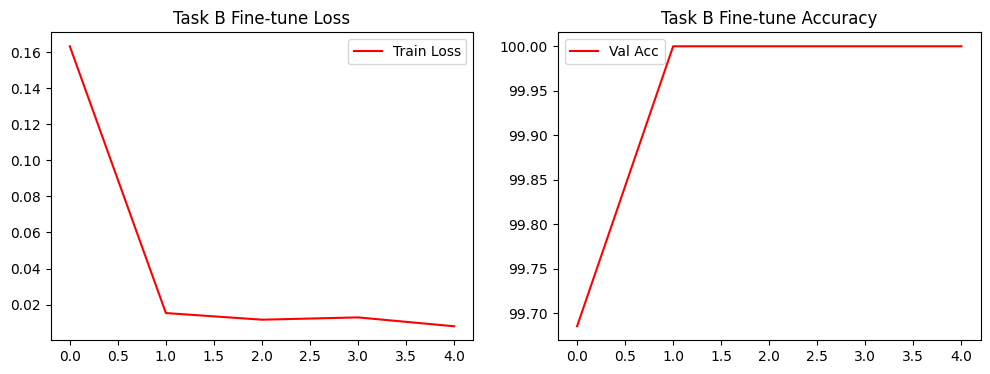

✅ 任务 B 训练完成！


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

# ======================
# 超参数
# ======================
batch_size = 32
epochs = 5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ======================
# 数据（和任务A完全一样）
# ======================
data_dir = "./data/PlantVillage"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

num_classes = len(full_dataset.classes)

# ======================
# 任务 B：微调 ResNet18
# ======================
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# 冻结所有层
for param in model.parameters():
    param.requires_grad = False

# 只解冻 layer4 + fc
for param in model.layer4.parameters():
    param.requires_grad = True

# 替换分类头
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

# 损失 & 优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# ======================
# 训练函数
# ======================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def val_one_epoch(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    return 100 * correct / total

# ======================
# 开始训练
# ======================
train_loss_history = []
val_acc_history = []

print("===== 任务 B 微调训练开始 =====")
for epoch in range(epochs):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_acc = val_one_epoch(model, val_loader, device)

    train_loss_history.append(train_loss)
    val_acc_history.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f} | Val Acc: {val_acc:.2f}%\n")

# ======================
# 画图
# ======================
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_loss_history, label="Train Loss", color="red")
plt.title("Task B Fine-tune Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(val_acc_history, label="Val Acc", color="red")
plt.title("Task B Fine-tune Accuracy")
plt.legend()
plt.show()

# ======================
# 保存模型
# ======================
torch.save(model.state_dict(), "taskB_finetune.pth")
print("✅ 任务 B 训练完成！")